##**Importing Libraries**

In [ ]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import torchvision
import glob

##**Dataset**

**Data Preparation**

In [ ]:
class DiffusionDataset(Dataset):
    def __init__(self, npy_dir, transform=None):
        """
        Args:
            npy_dir (str): Path to the directory containing .npy files.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.npy_files = sorted(glob.glob(os.path.join(npy_dir, '*.npy')))
        self.transform = transform

    def __len__(self):
        return len(self.npy_files)

    def __getitem__(self, idx):
        file_path = self.npy_files[idx]
        image = np.load(file_path)  # Expected shape: (C, H, W)
        if self.transform:
            image = self.transform(image)
        return torch.tensor(image, dtype=torch.float32)

**Loading the data**

In [ ]:
dataset_dir = "/content/drive/MyDrive/Samples"  # <-- Update this!
dataset = DiffusionDataset(dataset_dir)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

##**Modelling**

**Defining the model**

In [ ]:
class DiffusionModel(nn.Module):
    def __init__(self, in_channels=1, base_channels=64): # <-- Changed in_channels to 1 to match data
        super(DiffusionModel, self).__init__()
        # Time embedding: we set the embedding dimension equal to base_channels
        self.time_embed = nn.Sequential(
            nn.Linear(1, base_channels),
            nn.ReLU(),
            nn.Linear(base_channels, base_channels)
        )
        self.conv1 = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1) # <-- in_channels matches the dataset
        self.conv2 = nn.Conv2d(base_channels, base_channels, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(base_channels, base_channels, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(base_channels, in_channels, kernel_size=3, padding=1)  # <-- in_channels matches the dataset

    def forward(self, x, t):
        """
        x: noisy image tensor of shape (batch, C, H, W)
        t: time step tensor of shape (batch,) (each entry is an int between 0 and T-1)
        """
        # Embed time: shape becomes (batch, base_channels)
        t = t.unsqueeze(1).float()  # shape: (batch, 1)
        t_emb = self.time_embed(t)  # shape: (batch, base_channels)
        # Reshape to add spatial dimensions: (batch, base_channels, 1, 1)
        t_emb = t_emb.unsqueeze(-1).unsqueeze(-1)
        # Add time embedding to features in each layer
        h = F.relu(self.conv1(x) + t_emb)
        h = F.relu(self.conv2(h) + t_emb)
        h = F.relu(self.conv3(h) + t_emb)
        h = self.conv4(h)
        return h

**Variance scheduling for the diffusion model**

In [ ]:
T = 1000  # Number of diffusion time steps
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, T)  # (T,)
alphas = 1.0 - betas                           # (T,)
alpha_bars = torch.cumprod(alphas, dim=0)

**Preparing the model**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DiffusionModel(in_channels=1, base_channels=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

**Training the model**

In [7]:
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    for batch in dataloader:
        batch = batch.to(device)  # Ground-truth images: x_0
        batch_size = batch.size(0)

        # Sample a random time step t for each image in the batch
        t = torch.randint(0, T, (batch_size,), device=device)
        # Gather alpha_bar for each t
        alpha_bar_t = alpha_bars[t].to(device)  # shape: (batch,)
        # Sample noise
        noise = torch.randn_like(batch)
        # Compute the noisy image x_t using: x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise
        sqrt_alpha_bar = alpha_bar_t.sqrt().view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar = (1 - alpha_bar_t).sqrt().view(-1, 1, 1, 1)
        x_t = sqrt_alpha_bar * batch + sqrt_one_minus_alpha_bar * noise

        # Model predicts the noise given x_t and t
        pred_noise = model(x_t, t)
        loss = criterion(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")

Epoch 1/10, Loss: 11.358002
Epoch 2/10, Loss: 0.826927
Epoch 3/10, Loss: 0.505825
Epoch 4/10, Loss: 0.194855
Epoch 5/10, Loss: 0.135608
Epoch 6/10, Loss: 0.087348
Epoch 7/10, Loss: 0.059370
Epoch 8/10, Loss: 0.053104
Epoch 9/10, Loss: 0.062523
Epoch 10/10, Loss: 0.166725


**Evaluate the model**

In [15]:
def sample_image(model, shape, T, betas, alphas, alpha_bars):
    model.eval()
    with torch.no_grad():
        # Start from pure Gaussian noise
        x = torch.randn(shape, device=device)
        for t in reversed(range(T)):
            t_tensor = torch.full((shape[0],), t, device=device, dtype=torch.long)
            # Predict the noise at time t
            epsilon = model(x, t_tensor)
            # Convert tensors for the current time step (as Python numbers)
            alpha = alphas[t].item()
            alpha_bar = alpha_bars[t].item()
            beta = betas[t].item()
            sqrt_recip_alpha = 1 / math.sqrt(alpha)
            sqrt_one_minus_alpha_bar = math.sqrt(1 - alpha_bar)
            # For t > 0, add noise; for t == 0, no noise is added.
            noise = torch.randn_like(x) if t > 0 else 0
            # Reverse diffusion update:
            x = sqrt_recip_alpha * (x - ((1 - alpha) / sqrt_one_minus_alpha_bar) * epsilon) + math.sqrt(beta) * noise
        return x

In [16]:
sampled_images = sample_image(model, (16, 1, 64, 64), T, betas, alphas, alpha_bars)
# Clamp values to [0, 1] and move to CPU for visualization
sampled_images = sampled_images.cpu().clamp(0, 1)

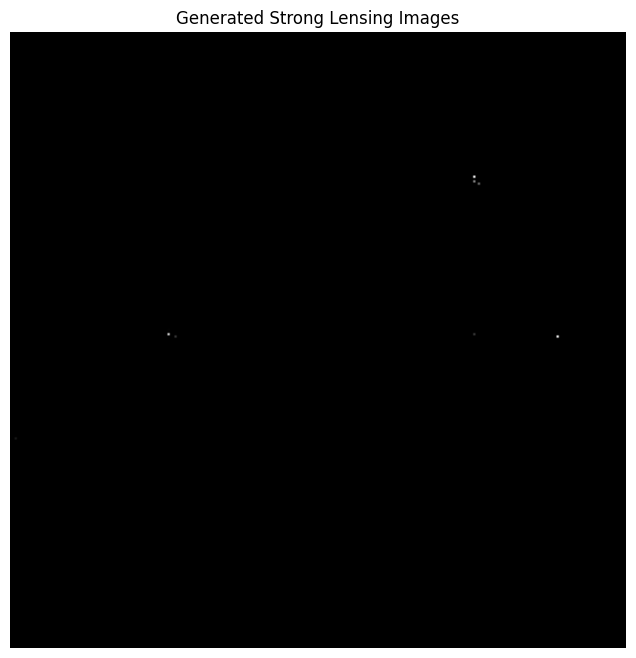

In [17]:
grid = torchvision.utils.make_grid(sampled_images, nrow=4)
plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1,2,0).numpy())
plt.title("Generated Strong Lensing Images")
plt.axis("off")
plt.show()

**Saving the model**

In [11]:
# Define the path where the model weights will be saved
model_path = "/content/cnn_weights4.pth"

# Save only the model's state_dict (recommended)
torch.save(model.state_dict(), model_path)

print(f"Model weights saved to {model_path}")

Model weights saved to /content/cnn_weights4.pth
